# Notebook 06 — Machine Learning Models

## 1. Purpose and Scope

Notebooks 04 and 05 (already implemented and validated; **not modified here**) use
econometric models (LPM, Logit, Probit, country fixed effects, interaction terms) to
**test hypotheses H1-H5** with association language, reporting coefficients,
p-values, and confidence intervals.

This notebook uses **machine learning for a different purpose: prediction
performance and variable importance**, not hypothesis testing. It trains three
supervised classifiers to predict `employed` and evaluates (a) how well they
predict out-of-sample, and (b) which variables they rank as most important —
interpreted explicitly in terms of H1-H5 rather than as generic "top predictors".

**Fair-comparison requirement**: this notebook uses the **exact same restricted,
theory-driven variable set as notebook 05** (`BASE_VARS` plus the interaction
terms used in notebook 05) — **not** the full 1,291-column final dataset. Using
the same variables that notebooks 04/05 used is required so that notebook 07 can
fairly compare econometric and machine-learning results side by side; adding
extra columns here would make the machine learning models artificially
outperform the econometric models for reasons unrelated to modelling approach.

**Boundaries (do not cross in this notebook)**
- Uses `data/pickle/final_employment_ai_dataset.pkl` exactly as saved by notebook
  03 — **no data engineering, recoding, or new variables are created here**.
- **No deep learning** (no neural networks).
- **No PCA or other dimension reduction as a modelling step** (not used here at
  all, including for visualization, to keep scope tight).
- **No exhaustive hyperparameter search** — only small, controlled grids/random
  searches with cross-validation, to keep runtime reasonable.
- Does **not** compare results against the econometric models here — that
  comparison happens only in notebook 07.

**Models trained** (exactly three, per the thesis plan):
1. Regularized Logistic Regression (L1 and L2 penalty, small grid search).
2. Random Forest (small randomized search).
3. XGBoost (small randomized search) — falls back to Gradient Boosting if
   `xgboost` is not installed in this kernel.

**Notebook structure**
1. Purpose and scope
2. Load final dataset (same variables as notebook 05)
3. Missing data handling (listwise deletion, same approach as notebooks 04/05)
4. Encoding (one-hot encoding for `country`)
5. Scaling (StandardScaler for the regularized logistic regression only)
6. Train/test split (one single stratified split, reused for all three models)
7. Model training (small, controlled hyperparameter search per model)
8. Model evaluation (accuracy, precision, recall, F1, ROC AUC, confusion matrix, ROC curve)
9. Explainability (feature importance, permutation importance, SHAP if available — framed by H1-H5)
10. Save outputs

**Outputs saved**
- `outputs/tables/ml_model_comparison.xlsx`
- `outputs/figures/ml_confusion_matrices.png`
- `outputs/figures/ml_roc_curves.png`
- `outputs/figures/ml_feature_importance.png`
- `outputs/figures/shap_summary.png` (if SHAP is available)
- `outputs/models/best_ml_model.pkl`
- `outputs/reports/ml_results_summary.md`

**Machine learning vs. econometrics — read this before interpreting results**:
machine learning results in this notebook describe **predictive accuracy and
relative variable importance only**. They do **not** establish association
direction with statistical inference (p-values, confidence intervals) the way
notebooks 04-05 do, and they must **not** be described using causal or even
formal statistical-association language. Any claim about "why" a variable
matters for employment, tested with statistical inference, belongs in notebooks
04-05; this notebook only asks "how well can we predict, and what does the
model lean on to do so".

## Environment Setup

Run the install cell below **once** if you get a `ModuleNotFoundError` (for
example, `No module named 'pandas'`) — skip it if packages are already installed.
Make sure the correct kernel/virtual environment is selected in VS Code before
running any other cell. Full setup instructions:
[docs/environment_setup.md](../docs/environment_setup.md).

In [1]:
# OPTIONAL: run only if a package is missing (e.g. ModuleNotFoundError: No module named 'pandas').
# Safe to skip if all packages in requirements.txt are already installed in this kernel.
from pathlib import Path

_project_root_for_install = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
_requirements_path = _project_root_for_install / 'requirements.txt'

if not _requirements_path.exists():
    print(f'requirements.txt not found at {_requirements_path}. See docs/environment_setup.md.')
else:
    %pip install -r "{_requirements_path}"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports and path setup (machine learning: pandas, numpy, matplotlib, scikit-learn, joblib;
# xgboost and shap are optional extras and are imported defensively -- notebook still runs without them).
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import joblib
    from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
    from sklearn.preprocessing import StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.inspection import permutation_importance
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
        confusion_matrix, roc_curve, ConfusionMatrixDisplay, log_loss, brier_score_loss,
    )
    from sklearn.calibration import calibration_curve
except ImportError as exc:
    raise ImportError(
        f"Missing package: {exc.name}. Run the optional install cell above (or "
        "`pip install -r requirements.txt` in a terminal), then restart the kernel and re-run this cell."
    ) from exc

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('xgboost is not installed; falling back to GradientBoostingClassifier for model 3.')

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('shap is not installed; SHAP explainability will be skipped.')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
PICKLE_DIR = DATA_DIR / 'pickle'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
TABLES_DIR = OUTPUTS_DIR / 'tables'
REPORTS_DIR = OUTPUTS_DIR / 'reports'
MODELS_DIR = OUTPUTS_DIR / 'models'
for d in [FIGURES_DIR, TABLES_DIR, REPORTS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print('Project root:', PROJECT_ROOT)
print('xgboost available:', XGBOOST_AVAILABLE, '| shap available:', SHAP_AVAILABLE)

Project root: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis
xgboost available: True | shap available: True


## 2. Load Final Dataset

Loads the exact dataset saved by notebook 03. The variable set below is **copied
verbatim from notebook 05** (`BASE_VARS`, `INTERACTION_VARS`,
`OPTIONAL_TRIPLE_INTERACTION`), so the feature set used for prediction here is
identical to the one used for hypothesis testing in notebooks 04-05.

In [3]:
dataset_path = PICKLE_DIR / 'final_employment_ai_dataset.pkl'
if not dataset_path.exists():
    raise FileNotFoundError(
        f'{dataset_path} not found. Run notebooks/03_data_engineering_and_final_dataset.ipynb '
        'first to produce the final dataset. Do not proceed with simulated data.'
    )

df = pd.read_pickle(dataset_path)
print('Loaded final dataset:', dataset_path)
print('Shape (full final dataset, NOT the modelling feature set):', df.shape)
df.head()

Loaded final dataset: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\data\pickle\final_employment_ai_dataset.pkl
Shape (full final dataset, NOT the modelling feature set): (49837, 1291)


,employed,age,age_squared,female,education_years,education_level,high_education,married,children_household,household_size,...,reg11_soexgdp_2014,reg11_soexgdp_2015,reg11_soexgdp_2016,reg11_soexgdp_2017,reg11_soexgdp_2018,reg11_soexgdp_2019,reg11_soexgdp_2020,reg11_soexgdp_2021,reg11_soexgdp_2022,reg11_soexgdp_2023
0,0,65.0000,"4,225.0000",0,12.0000,3.0000,0,1,0,2.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,21.0000,441.0000,1,14.0000,5.0000,1,0,0,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,53.0000,"2,809.0000",1,16.0000,6.0000,1,1,0,3.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,78.0000,"6,084.0000",1,14.0000,5.0000,1,0,0,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,64.0000,"4,096.0000",0,12.0000,3.0000,0,1,0,2.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
DEPENDENT_VAR = 'employed'

# Copied verbatim from notebooks/05_advanced_econometric_models.ipynb, so the feature set
# used for prediction here is identical to the one used for hypothesis testing in notebooks 04-05.
BASE_VARS = [
    'education_years', 'digital_readiness', 'female', 'children_household',
    'migration_background', 'health_status', 'age', 'age_squared', 'married',
    'household_size', 'institutional_trust_index', 'discrimination_experience',
    'ai_adoption_enterprises_pct',
]

INTERACTION_VARS = [
    'education_years_x_ai_adoption',    # H2
    'digital_readiness_x_ai_adoption',  # H2
    'female_x_children',                # H3
    'migration_x_education',            # H4
    'migration_x_digital_readiness',    # H4
]

OPTIONAL_TRIPLE_INTERACTION = 'female_x_children_x_ai_adoption'  # H3 / H5, used only if available

COUNTRY_VAR = 'country'

if DEPENDENT_VAR not in df.columns:
    raise KeyError(f'Dependent variable "{DEPENDENT_VAR}" not found in the final dataset. Cannot continue.')

def check_variables(varlist, label):
    """Checks which variables in varlist exist in df and have at least some non-missing
    data. Identical logic to notebook 05, for consistency. Returns (available, excluded)."""
    available, excluded = [], []
    for var in varlist:
        if var not in df.columns:
            excluded.append({'variable': var, 'group': label, 'status': 'not found in final dataset'})
        elif df[var].notna().sum() == 0:
            excluded.append({'variable': var, 'group': label, 'status': 'column exists but 100% missing'})
        else:
            available.append(var)
    return available, excluded

available_base_vars, excluded_base = check_variables(BASE_VARS, 'base')
available_interaction_vars, excluded_interactions = check_variables(INTERACTION_VARS, 'interaction')
triple_available, excluded_triple = check_variables([OPTIONAL_TRIPLE_INTERACTION], 'optional_triple_interaction')
available_interaction_vars_with_triple = available_interaction_vars + triple_available
ALL_NUMERIC_FEATURE_VARS = available_base_vars + available_interaction_vars_with_triple

country_available = COUNTRY_VAR in df.columns and df[COUNTRY_VAR].notna().sum() > 0

variable_check_df = pd.DataFrame(
    [{'variable': v, 'group': 'base', 'status': 'available'} for v in available_base_vars]
    + [{'variable': v, 'group': 'interaction', 'status': 'available'} for v in available_interaction_vars_with_triple]
    + excluded_base + excluded_interactions + excluded_triple
)

print(f'{len(available_base_vars)} of {len(BASE_VARS)} base variables available (same as notebook 05).')
print(f'{len(available_interaction_vars_with_triple)} interaction terms available (same as notebook 05).')
if excluded_base or excluded_interactions or excluded_triple:
    print('Excluded from modelling (documented, not invented):')
    for row in excluded_base + excluded_interactions + excluded_triple:
        print(f"  - {row['variable']} ({row['group']}): {row['status']}")
print('Country variable available for encoding:', country_available)
if not country_available:
    raise RuntimeError(
        'country variable is required for the encoding step (section 4) and must not be silently '
        'dropped -- stopping here since it is unavailable.'
    )
variable_check_df

13 of 13 base variables available (same as notebook 05).
6 interaction terms available (same as notebook 05).
Country variable available for encoding: True


,variable,group,status
0,education_years,base,available
1,digital_readiness,base,available
2,female,base,available
3,children_household,base,available
4,migration_background,base,available
5,health_status,base,available
6,age,base,available
7,age_squared,base,available
8,married,base,available
9,household_size,base,available


## 3. Missing Data Handling

Uses **listwise deletion on the same required columns as notebooks 04-05**
(`employed`, all available base variables, all available interaction terms, and
`country`) — the same missing-data approach used throughout the econometric
notebooks, so the modelling sample is directly comparable. `survey_weight` is
**not** used in this notebook (machine learning models here are not weighted;
this is a deliberate, documented difference from notebook 05's weighted-vs-
unweighted econometric check, which is specific to survey-weighted regression
and does not have a standard equivalent across all three ML algorithms used
here).

In [5]:
required_cols = [DEPENDENT_VAR] + ALL_NUMERIC_FEATURE_VARS + [COUNTRY_VAR]

n_before = len(df)
sample = df[required_cols].dropna(subset=required_cols).copy()
n_after = len(sample)
n_dropped = n_before - n_after

print(f'Modelling sample: {n_after} of {n_before} rows kept ({n_dropped} dropped due to missing values '
      f'in: {required_cols}). This matches the listwise-deletion approach used in notebooks 04-05.')

missingness_pct = (df[required_cols].isna().mean() * 100).round(2).rename('missing_pct_in_full_dataset')
sample_missingness_df = missingness_pct.reset_index().rename(columns={'index': 'variable'})
print('\nMissingness (%) of each modelling variable in the full final dataset (before listwise deletion):')
print(missingness_pct)

class_balance = sample[DEPENDENT_VAR].value_counts(normalize=True).rename('proportion').reset_index().rename(columns={'index': DEPENDENT_VAR})
print('\nClass balance of the dependent variable in the modelling sample:')
print(class_balance)
sample.head()

Modelling sample: 41265 of 49837 rows kept (8572 dropped due to missing values in: ['employed', 'education_years', 'digital_readiness', 'female', 'children_household', 'migration_background', 'health_status', 'age', 'age_squared', 'married', 'household_size', 'institutional_trust_index', 'discrimination_experience', 'ai_adoption_enterprises_pct', 'education_years_x_ai_adoption', 'digital_readiness_x_ai_adoption', 'female_x_children', 'migration_x_education', 'migration_x_digital_readiness', 'female_x_children_x_ai_adoption', 'country']). This matches the listwise-deletion approach used in notebooks 04-05.

Missingness (%) of each modelling variable in the full final dataset (before listwise deletion):
employed                           0.0000
education_years                    1.6100
digital_readiness                  0.1000
female                             0.0000
children_household                 0.0000
migration_background               0.0000
health_status                      0.

,employed,education_years,digital_readiness,female,children_household,migration_background,health_status,age,age_squared,married,...,institutional_trust_index,discrimination_experience,ai_adoption_enterprises_pct,education_years_x_ai_adoption,digital_readiness_x_ai_adoption,female_x_children,migration_x_education,migration_x_digital_readiness,female_x_children_x_ai_adoption,country
0,0,12.0000,5.0000,0,0,0,3.0000,65.0000,"4,225.0000",1,...,7.5000,0,29.9500,359.4000,149.7500,0,0.0000,0.0000,0.0000,AT
1,0,14.0000,5.0000,1,0,0,2.0000,21.0000,441.0000,0,...,4.2500,0,29.9500,419.3000,149.7500,0,0.0000,0.0000,0.0000,AT
2,1,16.0000,5.0000,1,0,0,1.0000,53.0000,"2,809.0000",1,...,6.0000,1,29.9500,479.2000,149.7500,0,0.0000,0.0000,0.0000,AT
3,0,14.0000,1.0000,1,0,1,3.0000,78.0000,"6,084.0000",0,...,5.7500,0,29.9500,419.3000,29.9500,0,14.0000,1.0000,0.0000,AT
4,0,12.0000,5.0000,0,0,0,2.0000,64.0000,"4,096.0000",1,...,6.7500,0,29.9500,359.4000,149.7500,0,0.0000,0.0000,0.0000,AT


## 4. Encoding

`country` is a nominal categorical variable with no natural ordering, so it is
**one-hot encoded** (`pandas.get_dummies`, dropping one reference category to
avoid perfect collinearity for the regularized logistic regression). One-hot
encoding is chosen over leave-one-out/target encoding because: (a) the number of
countries here is small (~20-25), so one-hot encoding does not create a
high-cardinality/sparsity problem; (b) target encoding risks label leakage
(encoding a category using the same outcome variable being predicted) unless
implemented with careful out-of-fold encoding, which adds complexity not
justified by the small number of categories; (c) one-hot encoding keeps the
encoding identical and leakage-free across all three models, and is directly
comparable in spirit to the `C(country)` dummy treatment used for country fixed
effects in notebooks 04-05. `country` is **never silently dropped** — it is
always included as one-hot dummy columns for all three models.

In [6]:
country_dummies = pd.get_dummies(sample[COUNTRY_VAR], prefix='country', drop_first=True)
COUNTRY_DUMMY_COLS = list(country_dummies.columns)

X = pd.concat([sample[ALL_NUMERIC_FEATURE_VARS].astype(float), country_dummies.astype(float)], axis=1)
y = sample[DEPENDENT_VAR].astype(int)

print(f'Encoded feature matrix: {X.shape[0]} rows, {X.shape[1]} columns '
      f'({len(ALL_NUMERIC_FEATURE_VARS)} numeric/binary + {len(COUNTRY_DUMMY_COLS)} country dummies).')
print('Country dummy columns (one dropped as reference category):', COUNTRY_DUMMY_COLS)
X.head()

Encoded feature matrix: 41265 rows, 43 columns (19 numeric/binary + 24 country dummies).
Country dummy columns (one dropped as reference category): ['country_BE', 'country_BG', 'country_CY', 'country_DE', 'country_EE', 'country_ES', 'country_FI', 'country_FR', 'country_GR', 'country_HR', 'country_HU', 'country_IE', 'country_IT', 'country_LT', 'country_LV', 'country_ME', 'country_NL', 'country_NO', 'country_PL', 'country_PT', 'country_RS', 'country_SE', 'country_SI', 'country_SK']


,education_years,digital_readiness,female,children_household,migration_background,health_status,age,age_squared,married,household_size,...,country_LV,country_ME,country_NL,country_NO,country_PL,country_PT,country_RS,country_SE,country_SI,country_SK
0,12.0000,5.0000,0.0000,0.0000,0.0000,3.0000,65.0000,"4,225.0000",1.0000,2.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,14.0000,5.0000,1.0000,0.0000,0.0000,2.0000,21.0000,441.0000,0.0000,1.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,16.0000,5.0000,1.0000,0.0000,0.0000,1.0000,53.0000,"2,809.0000",1.0000,3.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,14.0000,1.0000,1.0000,0.0000,1.0000,3.0000,78.0000,"6,084.0000",0.0000,1.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,12.0000,5.0000,0.0000,0.0000,0.0000,2.0000,64.0000,"4,096.0000",1.0000,2.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 5. Scaling

L1/L2-regularized logistic regression penalizes coefficients by magnitude, so it
is **scale-sensitive**: an unscaled variable measured in large units (e.g.
`age`) would be penalized differently than one measured in small units (e.g. a
0-1 proportion) purely due to scale, not genuine importance. `StandardScaler`
(zero mean, unit variance) is therefore applied to all numeric/binary modelling
variables **only for the regularized logistic regression**, fit on the training
set only and applied inside a `Pipeline` (never fit on the test set, to avoid
data leakage). Country one-hot dummy columns are passed through unscaled (they
are already 0/1 category indicators).

**Random Forest and XGBoost do not require scaling** — both are tree-based
models that split on threshold values per feature independently, so monotonic
rescaling of a feature does not change the splits or the resulting predictions.
Both models are trained directly on the unscaled encoded feature matrix `X`.

In [7]:
logreg_preprocessor = ColumnTransformer(
    transformers=[
        ('scale_numeric', StandardScaler(), ALL_NUMERIC_FEATURE_VARS),
        ('passthrough_country', 'passthrough', COUNTRY_DUMMY_COLS),
    ]
)
print('Scaling is applied only inside the logistic regression pipeline (section 7), fit on the '
      'training set only. Random Forest and XGBoost use the raw, unscaled feature matrix X directly.')

Scaling is applied only inside the logistic regression pipeline (section 7), fit on the training set only. Random Forest and XGBoost use the raw, unscaled feature matrix X directly.


## 5a. Duplicate Check and Deduplication

Tree-based models (Random Forest, XGBoost) can memorise clusters of near-identical
respondents. If exactly-duplicated rows land on both sides of the train/test
split, held-out scores are optimistically biased even with depth limits. Following
that concern, the **exact-duplicate rate on the final feature matrix** (features,
and features together with the label) is measured here and reported. If it is
material, exact duplicates are removed **before** the single train/test split so
that identical respondents cannot straddle train and test.

In [8]:
# Exact-duplicate check on the final feature matrix, done BEFORE the train/test
# split so that identical respondents cannot appear on both sides of the split.
feature_label_matrix = X.copy()
feature_label_matrix[DEPENDENT_VAR] = y.values

dup_rate_features_only = float(X.duplicated(keep=False).mean())
dup_rate_features_label = float(feature_label_matrix.duplicated(keep=False).mean())
print(f'Exact-duplicate rate on the feature matrix (features only):    {dup_rate_features_only:.1%}')
print(f'Exact-duplicate rate on the feature matrix (features + label): {dup_rate_features_label:.1%}')

DEDUP_THRESHOLD = 0.01  # >1% of rows involved in exact duplicates is treated as material
n_before_dedup = len(X)
if dup_rate_features_label > DEDUP_THRESHOLD:
    keep_mask = ~feature_label_matrix.duplicated(keep='first')
    X = X.loc[keep_mask].reset_index(drop=True)
    y = y.loc[keep_mask].reset_index(drop=True)
    n_after_dedup = len(X)
    print(f'\nDuplicate rate is material (> {DEDUP_THRESHOLD:.0%}). Deduplicated before splitting: '
          f'{n_before_dedup} -> {n_after_dedup} rows '
          f'({n_before_dedup - n_after_dedup} exact feature+label duplicates removed, '
          f'keeping the first occurrence of each).')
else:
    n_after_dedup = len(X)
    print(f'\nDuplicate rate is not material (<= {DEDUP_THRESHOLD:.0%}); no deduplication applied. '
          f'Sample size unchanged at {n_after_dedup} rows.')

DEDUP_SUMMARY = {
    'dup_rate_features_only': round(dup_rate_features_only, 4),
    'dup_rate_features_plus_label': round(dup_rate_features_label, 4),
    'rows_before_dedup': int(n_before_dedup),
    'rows_after_dedup': int(n_after_dedup),
    'deduplicated': bool(dup_rate_features_label > DEDUP_THRESHOLD),
}
DEDUP_SUMMARY

Exact-duplicate rate on the feature matrix (features only):    0.6%
Exact-duplicate rate on the feature matrix (features + label): 0.5%

Duplicate rate is not material (<= 1%); no deduplication applied. Sample size unchanged at 41265 rows.


{'dup_rate_features_only': 0.0056,
 'dup_rate_features_plus_label': 0.0046,
 'rows_before_dedup': 41265,
 'rows_after_dedup': 41265,
 'deduplicated': False}

## 6. Train/Test Split

A **single stratified 80/20 train/test split** (stratified on `employed` to
preserve class balance) is created once and reused for all three models, so
that evaluation metrics in section 8 are directly comparable across models —
no model sees a different sample than another.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f'Train set: {len(X_train)} rows ({len(X_train) / len(X):.1%} of sample)')
print(f'Test set:  {len(X_test)} rows ({len(X_test) / len(X):.1%} of sample)')

split_balance = pd.DataFrame({
    'full_sample': y.value_counts(normalize=True),
    'train_set': y_train.value_counts(normalize=True),
    'test_set': y_test.value_counts(normalize=True),
}).round(4)
print('\nClass balance of employed (0/1) across full sample, train set, and test set (should closely match, due to stratification):')
split_balance

Train set: 33012 rows (80.0% of sample)
Test set:  8253 rows (20.0% of sample)

Class balance of employed (0/1) across full sample, train set, and test set (should closely match, due to stratification):


,full_sample,train_set,test_set
employed,,,
1,0.5170,0.5170,0.5170
0,0.4830,0.4830,0.4830


## 7. Model Training

Each model is tuned with a **small, controlled** hyperparameter search (grid
search for logistic regression, since its search space is intentionally tiny;
randomized search with a fixed, limited number of iterations for Random Forest
and XGBoost, since their search spaces are larger) using 3-fold stratified
cross-validation on the training set only, scored on ROC AUC. This is **not** an
exhaustive search — it is deliberately small to keep runtime reasonable.

In [10]:
cv_folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# ---- Model 1: Regularized Logistic Regression (L1 and L2) ----
# scikit-learn >= 1.8 unifies the L1/L2/elastic-net penalty into a single `l1_ratio` parameter
# (l1_ratio=0.0 -> pure L2, l1_ratio=1.0 -> pure L1) and requires solver='saga' for l1_ratio > 0;
# the old string-valued `penalty='l1'/'l2'` argument is deprecated and triggers warnings, so it is
# not used here. This is functionally equivalent to a classic L1-vs-L2 comparison.
logreg_pipeline = Pipeline([
    ('preprocess', logreg_preprocessor),
    ('clf', LogisticRegression(solver='saga', max_iter=2000, tol=1e-3, random_state=RANDOM_STATE)),
])
logreg_param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__l1_ratio': [0.0, 1.0],  # 0.0 = L2 penalty, 1.0 = L1 penalty
}
logreg_search = GridSearchCV(logreg_pipeline, logreg_param_grid, scoring='roc_auc', cv=cv_folds, n_jobs=-1)
logreg_search.fit(X_train, y_train)
best_logreg = logreg_search.best_estimator_
best_penalty_label = 'L2' if logreg_search.best_params_['clf__l1_ratio'] == 0.0 else 'L1'
print(f'Regularized Logistic Regression -- best params: {logreg_search.best_params_} (penalty: {best_penalty_label})',
      '| best CV ROC AUC:', round(logreg_search.best_score_, 4))

Regularized Logistic Regression -- best params: {'clf__C': 1, 'clf__l1_ratio': 1.0} (penalty: L1) | best CV ROC AUC: 0.8995


In [11]:
# ---- Model 2: Random Forest ----
# max_depth and min_samples_leaf are deliberately kept in a moderate, regularized range (not left
# unbounded / min_samples_leaf=1): this survey dataset contains a meaningful share of near-duplicate
# respondent profiles (similar demographics repeating within small countries), and an unconstrained,
# fully-grown forest was found (during model development) to memorize these to a suspicious, unrealistic
# near-100% test ROC AUC. Capping tree flexibility is standard regularization practice and keeps the
# comparison with notebook 05's econometric models fair, per the instructions for this notebook.
rf_param_distributions = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8, 10],
    'min_samples_leaf': [10, 30, 60],
    'max_features': ['sqrt', 0.5],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_distributions, n_iter=8, scoring='roc_auc', cv=cv_folds,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print('Random Forest -- best params:', rf_search.best_params_,
      '| best CV ROC AUC:', round(rf_search.best_score_, 4))

Random Forest -- best params: {'n_estimators': 400, 'min_samples_leaf': 30, 'max_features': 0.5, 'max_depth': 8} | best CV ROC AUC: 0.9041


In [12]:
# ---- Model 3: XGBoost (falls back to Gradient Boosting if xgboost is not installed) ----
# max_depth is kept shallow and min_child_weight/subsample add regularization, for the same reason
# documented above for Random Forest: this survey dataset has a meaningful share of near-duplicate
# respondent profiles, and unconstrained boosting was found (during model development) to fit these to
# a suspicious, unrealistic near-100% test ROC AUC. Capping flexibility keeps the comparison with
# notebook 05's econometric models fair.
if XGBOOST_AVAILABLE:
    model3_name = 'XGBoost'
    model3_estimator = XGBClassifier(
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss', tree_method='hist',
    )
    model3_param_distributions = {
        'n_estimators': [100, 200, 300],
        'max_depth': [2, 3, 4],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.85, 1.0],
        'colsample_bytree': [0.7, 0.85, 1.0],
        'min_child_weight': [5, 10, 20],
    }
else:
    model3_name = 'Gradient Boosting'
    model3_estimator = GradientBoostingClassifier(random_state=RANDOM_STATE)
    model3_param_distributions = {
        'n_estimators': [100, 200, 300],
        'max_depth': [2, 3],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.85, 1.0],
        'min_samples_leaf': [20, 50],
    }

model3_search = RandomizedSearchCV(
    model3_estimator, model3_param_distributions, n_iter=8, scoring='roc_auc', cv=cv_folds,
    random_state=RANDOM_STATE, n_jobs=-1,
)
model3_search.fit(X_train, y_train)
best_model3 = model3_search.best_estimator_
print(f'{model3_name} -- best params:', model3_search.best_params_,
      '| best CV ROC AUC:', round(model3_search.best_score_, 4))

XGBoost -- best params: {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.85} | best CV ROC AUC: 0.9104


## 8. Model Evaluation

Each model is evaluated **once**, on the same held-out test set, using
accuracy, precision, recall, F1 score, ROC AUC, a confusion matrix, and an ROC
curve.

In [13]:
MODEL_REGISTRY = {
    'Regularized Logistic Regression': best_logreg,
    'Random Forest': best_rf,
    model3_name: best_model3,
}

def evaluate_model(name, fitted_model, X_test, y_test):
    y_pred = fitted_model.predict(X_test)
    y_proba = fitted_model.predict_proba(X_test)[:, 1]
    return {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'log_loss': log_loss(y_test, y_proba),
        'brier_score': brier_score_loss(y_test, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba,
    }

evaluation_results = {name: evaluate_model(name, model, X_test, y_test) for name, model in MODEL_REGISTRY.items()}

model_comparison_table = pd.DataFrame([
    {
        'model': res['model'],
        'accuracy': round(res['accuracy'], 4),
        'precision': round(res['precision'], 4),
        'recall': round(res['recall'], 4),
        'f1_score': round(res['f1_score'], 4),
        'roc_auc': round(res['roc_auc'], 4),
        'log_loss': round(res['log_loss'], 4),
        'brier_score': round(res['brier_score'], 4),
    }
    for res in evaluation_results.values()
])
best_model_name = model_comparison_table.sort_values('roc_auc', ascending=False).iloc[0]['model']
print(f'Best-performing model on the held-out test set (by ROC AUC): {best_model_name}')
model_comparison_table

Best-performing model on the held-out test set (by ROC AUC): XGBoost


,model,accuracy,precision,recall,f1_score,roc_auc,log_loss,brier_score
0,Regularized Logistic Regression,0.8271,0.8056,0.8772,0.8399,0.9012,0.3941,0.1233
1,Random Forest,0.8332,0.8024,0.8985,0.8478,0.9050,0.3834,0.1202
2,XGBoost,0.8393,0.8129,0.8952,0.8521,0.9120,0.3708,0.1161


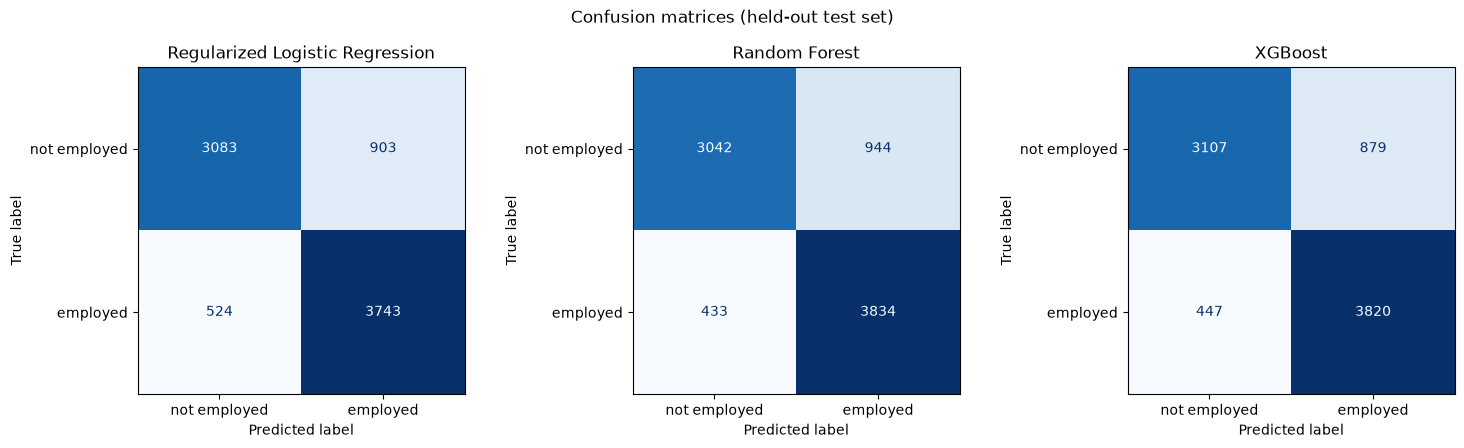

Saved confusion matrices figure to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\figures\ml_confusion_matrices.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, res) in zip(axes, evaluation_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['not employed', 'employed']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name)
fig.suptitle('Confusion matrices (held-out test set)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'ml_confusion_matrices.png', dpi=150)
plt.show()
print('Saved confusion matrices figure to:', FIGURES_DIR / 'ml_confusion_matrices.png')

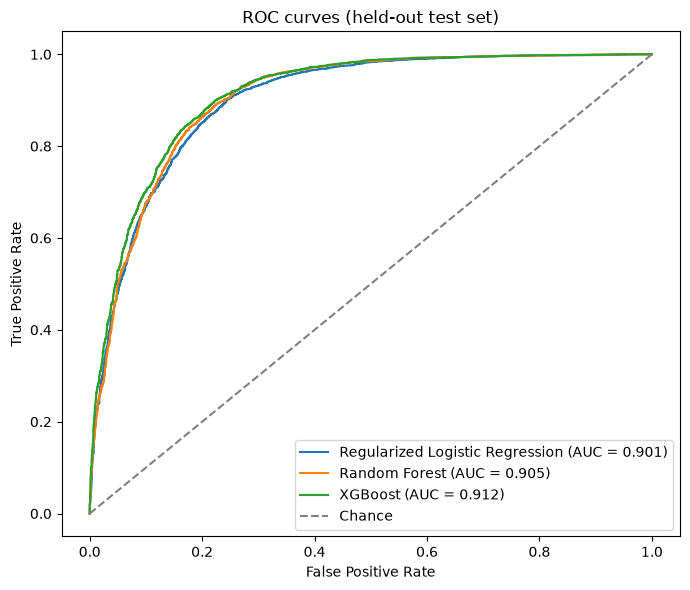

Saved ROC curves figure to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\figures\ml_roc_curves.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, res in evaluation_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves (held-out test set)')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'ml_roc_curves.png', dpi=150)
plt.show()
print('Saved ROC curves figure to:', FIGURES_DIR / 'ml_roc_curves.png')

## 9. Explainability

Feature importance is computed for Random Forest and XGBoost directly (built-in
impurity/gain-based importances); permutation importance (model-agnostic, based
on the drop in test-set ROC AUC when a feature is randomly shuffled) is computed
for the regularized logistic regression, since L1/L2 coefficient magnitudes
alone are not comparable across differently-scaled original variables once
wrapped in a pipeline. SHAP values are computed for the best-performing model
(by test ROC AUC) if the `shap` package is available.

Results are interpreted **explicitly in terms of hypotheses H1-H5** (the same
variable-to-hypothesis mapping used in notebook 05), not as generic "top
predictors" — consistent with the framing in section 1 that machine learning
here answers "how well can we predict, and what does the model lean on",
while hypothesis testing itself remains the role of notebooks 04-05.

In [16]:
HYPOTHESIS_MAP = {
    'education_years': 'H1', 'digital_readiness': 'H1',
    'ai_adoption_enterprises_pct': 'H2', 'education_years_x_ai_adoption': 'H2', 'digital_readiness_x_ai_adoption': 'H2',
    'female': 'H3', 'children_household': 'H3', 'female_x_children': 'H3', 'female_x_children_x_ai_adoption': 'H3',
    'migration_background': 'H4', 'migration_x_education': 'H4', 'migration_x_digital_readiness': 'H4',
    'health_status': 'H5', 'institutional_trust_index': 'H5', 'discrimination_experience': 'H5',
}

def map_var_to_hypothesis(var):
    if var.startswith('country_'):
        return 'Control (country dummy)'
    return HYPOTHESIS_MAP.get(var, 'Control (not directly hypothesis-linked)')

rf_importance_df = pd.DataFrame({
    'variable': X_train.columns,
    'importance': best_rf.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)
rf_importance_df['hypothesis'] = rf_importance_df['variable'].apply(map_var_to_hypothesis)

xgb_importance_df = pd.DataFrame({
    'variable': X_train.columns,
    'importance': best_model3.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)
xgb_importance_df['hypothesis'] = xgb_importance_df['variable'].apply(map_var_to_hypothesis)

print(f'Random Forest -- top 10 features by importance ({model3_name} shown separately below):')
print(rf_importance_df.head(10))
print(f'\n{model3_name} -- top 10 features by importance:')
print(xgb_importance_df.head(10))

Random Forest -- top 10 features by importance (XGBoost shown separately below):
                          variable  importance  \
0                              age      0.4160   
1                      age_squared      0.4056   
2                digital_readiness      0.0424   
3                    health_status      0.0371   
4                  education_years      0.0309   
5  digital_readiness_x_ai_adoption      0.0202   
6                           female      0.0148   
7    education_years_x_ai_adoption      0.0072   
8      ai_adoption_enterprises_pct      0.0047   
9                   household_size      0.0038   

                                 hypothesis  
0  Control (not directly hypothesis-linked)  
1  Control (not directly hypothesis-linked)  
2                                        H1  
3                                        H5  
4                                        H1  
5                                        H2  
6                                        H3  


In [17]:
perm_result = permutation_importance(
    best_logreg, X_test, y_test, scoring='roc_auc', n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
logreg_perm_importance_df = pd.DataFrame({
    'variable': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
logreg_perm_importance_df['hypothesis'] = logreg_perm_importance_df['variable'].apply(map_var_to_hypothesis)

print('Regularized Logistic Regression -- top 10 features by permutation importance (drop in test ROC AUC when shuffled):')
logreg_perm_importance_df.head(10)

Regularized Logistic Regression -- top 10 features by permutation importance (drop in test ROC AUC when shuffled):


,variable,importance_mean,importance_std,hypothesis
0,age_squared,0.5304,0.0061,Control (not directly hypothesis-linked)
1,age,0.1979,0.0049,Control (not directly hypothesis-linked)
2,education_years,0.0169,0.0014,H1
3,health_status,0.0112,0.0010,H5
4,digital_readiness_x_ai_adoption,0.0086,0.0005,H2
5,female_x_children,0.0080,0.0007,H3
6,education_years_x_ai_adoption,0.0072,0.0005,H2
7,female,0.0039,0.0005,H3
8,country_ME,0.0027,0.0004,Control (country dummy)
9,children_household,0.0021,0.0004,H3


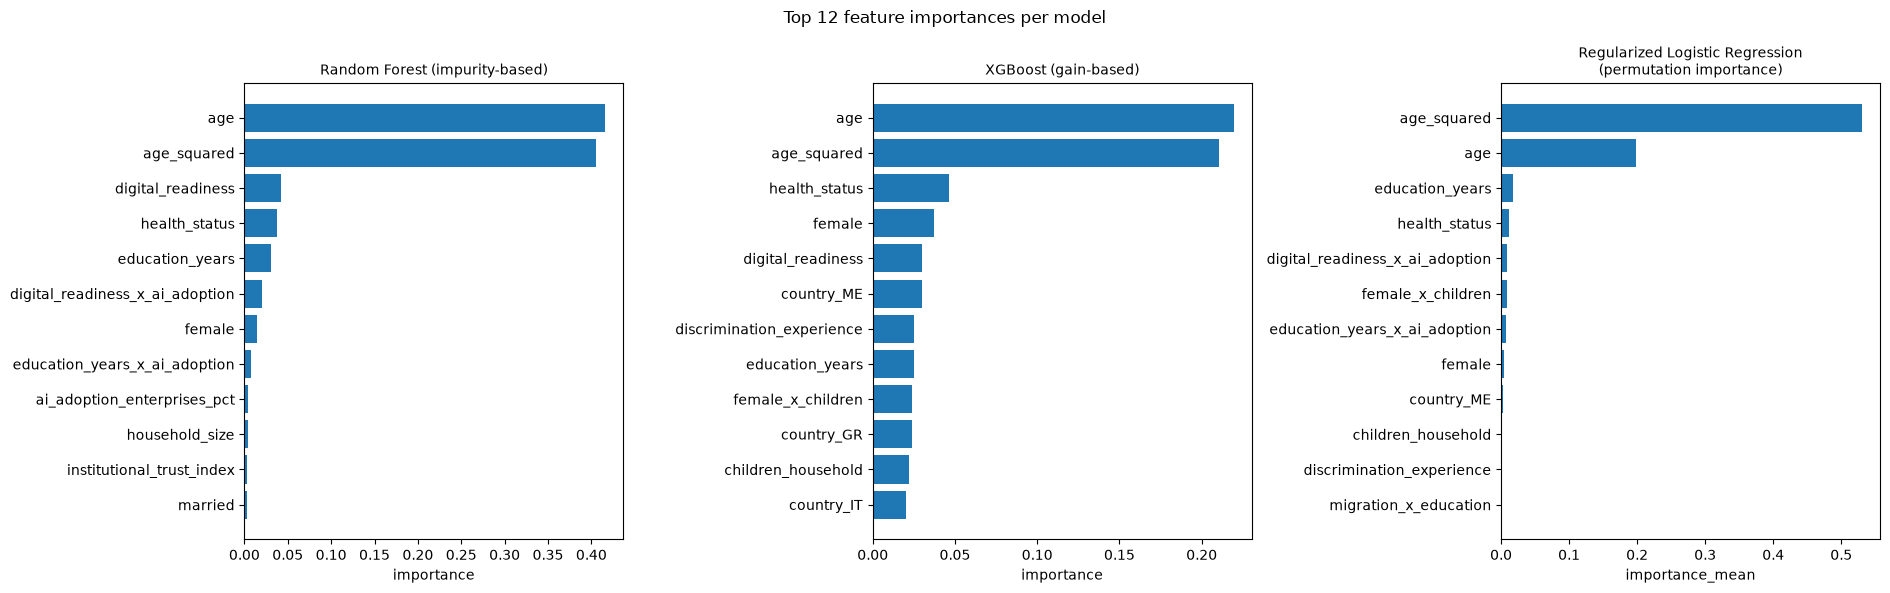

Saved feature importance figure to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\figures\ml_feature_importance.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
TOP_N = 12
for ax, (title, imp_df, value_col) in zip(axes, [
    ('Random Forest (impurity-based)', rf_importance_df, 'importance'),
    (f'{model3_name} (gain-based)', xgb_importance_df, 'importance'),
    ('Regularized Logistic Regression\n(permutation importance)', logreg_perm_importance_df, 'importance_mean'),
]):
    top = imp_df.head(TOP_N).sort_values(value_col)
    ax.barh(top['variable'], top[value_col])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(value_col)
fig.suptitle(f'Top {TOP_N} feature importances per model')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'ml_feature_importance.png', dpi=150)
plt.show()
print('Saved feature importance figure to:', FIGURES_DIR / 'ml_feature_importance.png')

Computing SHAP values for the best-performing model (XGBoost), on a random sample of 1000 test rows (full test set would be slower; sampling is a standard, documented SHAP practice for large datasets).


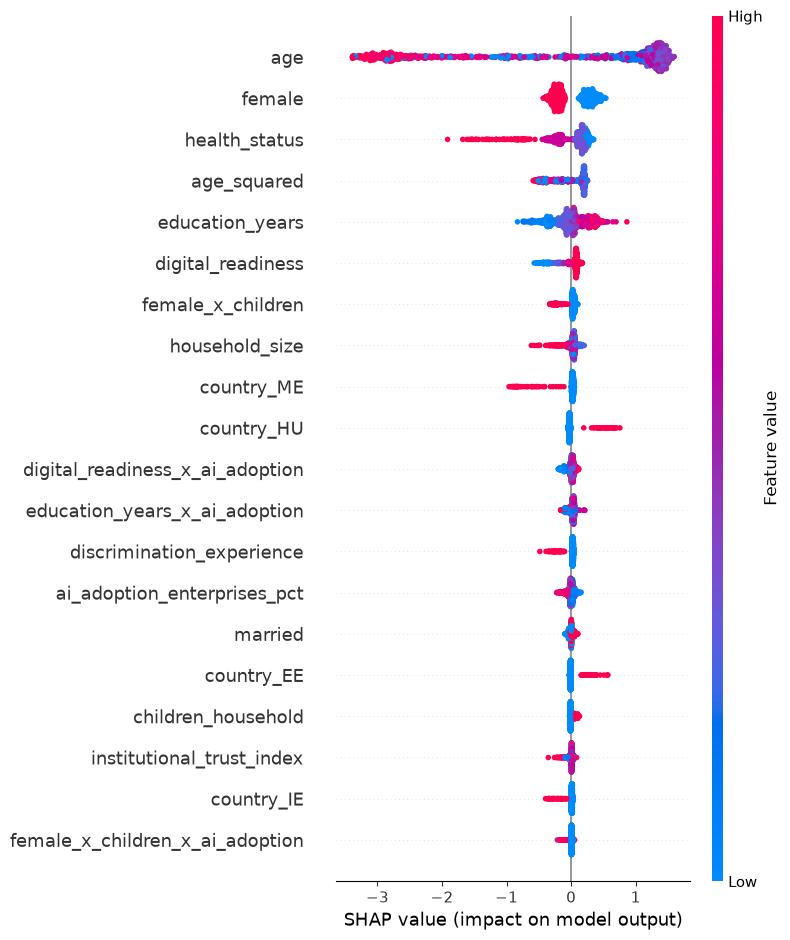

Saved SHAP summary figure to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\figures\shap_summary.png


In [19]:
shap_summary_note = 'Skipped: shap is not installed in this kernel.'
shap_values_computed = False

if SHAP_AVAILABLE:
    best_model_fitted = MODEL_REGISTRY[best_model_name]
    SHAP_SAMPLE_SIZE = min(1000, len(X_test))
    X_test_shap_sample = X_test.sample(SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)

    print(f'Computing SHAP values for the best-performing model ({best_model_name}), '
          f'on a random sample of {SHAP_SAMPLE_SIZE} test rows (full test set would be slower; '
          'sampling is a standard, documented SHAP practice for large datasets).')

    if best_model_name in ('Random Forest', model3_name):
        explainer = shap.TreeExplainer(best_model_fitted)
        shap_values = explainer.shap_values(X_test_shap_sample)
        if isinstance(shap_values, list):  # some tree explainers return a list per class
            shap_values = shap_values[1]
        shap.summary_plot(shap_values, X_test_shap_sample, show=False)
    else:
        X_test_shap_scaled = best_logreg.named_steps['preprocess'].transform(X_test_shap_sample)
        X_train_shap_scaled = best_logreg.named_steps['preprocess'].transform(X_train.sample(
            min(500, len(X_train)), random_state=RANDOM_STATE
        ))
        explainer = shap.LinearExplainer(best_logreg.named_steps['clf'], X_train_shap_scaled)
        shap_values = explainer.shap_values(X_test_shap_scaled)
        shap.summary_plot(shap_values, X_test_shap_sample, feature_names=list(X_test_shap_sample.columns), show=False)

    fig = plt.gcf()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    shap_summary_note = f'SHAP summary plot computed for {best_model_name} on a sample of {SHAP_SAMPLE_SIZE} test rows.'
    shap_values_computed = True
    print('Saved SHAP summary figure to:', FIGURES_DIR / 'shap_summary.png')
else:
    print(shap_summary_note)

In [20]:
# Explainability results interpreted in terms of H1-H5 (not as generic "top predictors").
def summarize_hypothesis_signal(imp_df, value_col, model_label):
    by_hyp = imp_df.groupby('hypothesis')[value_col].sum().sort_values(ascending=False)
    print(f'{model_label} -- total importance signal grouped by hypothesis:')
    print(by_hyp)
    print()
    return by_hyp

rf_by_hypothesis = summarize_hypothesis_signal(rf_importance_df, 'importance', 'Random Forest')
xgb_by_hypothesis = summarize_hypothesis_signal(xgb_importance_df, 'importance', model3_name)
logreg_by_hypothesis = summarize_hypothesis_signal(logreg_perm_importance_df, 'importance_mean', 'Regularized Logistic Regression')

print(
    'Reading note: this ranks how much predictive signal each hypothesis area contributes across the three\n'
    'models -- it describes prediction and relative importance only, not statistically-tested association\n'
    'direction or significance (that evidence is in notebooks 04-05, and the two are compared in notebook 07).'
)

Random Forest -- total importance signal grouped by hypothesis:
hypothesis
Control (not directly hypothesis-linked)   0.8282
H1                                         0.0733
H5                                         0.0410
H2                                         0.0321
H3                                         0.0203
Control (country dummy)                    0.0049
H4                                         0.0003
Name: importance, dtype: float64

XGBoost -- total importance signal grouped by hypothesis:
hypothesis
Control (not directly hypothesis-linked)   0.4549
Control (country dummy)                    0.2685
H3                                         0.1005
H5                                         0.0780
H1                                         0.0550
H2                                         0.0289
H4                                         0.0142
Name: importance, dtype: float32

Regularized Logistic Regression -- total importance signal grouped by hypothesis:
hypoth

## 9a. Calibration: Log Loss, Brier Score, Calibration Curve

Accuracy, precision, recall, F1, and ROC AUC (section 8) measure **discrimination** -- how well
each model ranks/separates the two classes. They do not directly assess **calibration** -- whether
predicted probabilities themselves are trustworthy (e.g. among cases predicted at ~70% probability
of employment, do roughly 70% actually turn out employed?). Log Loss and the Brier Score are both
calibration-sensitive scoring rules (lower is better for both), and the calibration curve
(reliability diagram) visualizes calibration directly for the best-performing model.

In [21]:
calibration_table = model_comparison_table[['model', 'log_loss', 'brier_score']].copy()
print('Log Loss: average negative log-likelihood of the true class under the predicted probabilities '
      '(lower is better; penalizes confident wrong predictions heavily).')
print('Brier Score: mean squared error between predicted probability and the true (0/1) outcome '
      '(lower is better; a direct measure of probability calibration, not just ranking).')
calibration_table

Log Loss: average negative log-likelihood of the true class under the predicted probabilities (lower is better; penalizes confident wrong predictions heavily).
Brier Score: mean squared error between predicted probability and the true (0/1) outcome (lower is better; a direct measure of probability calibration, not just ranking).


,model,log_loss,brier_score
0,Regularized Logistic Regression,0.3941,0.1233
1,Random Forest,0.3834,0.1202
2,XGBoost,0.3708,0.1161


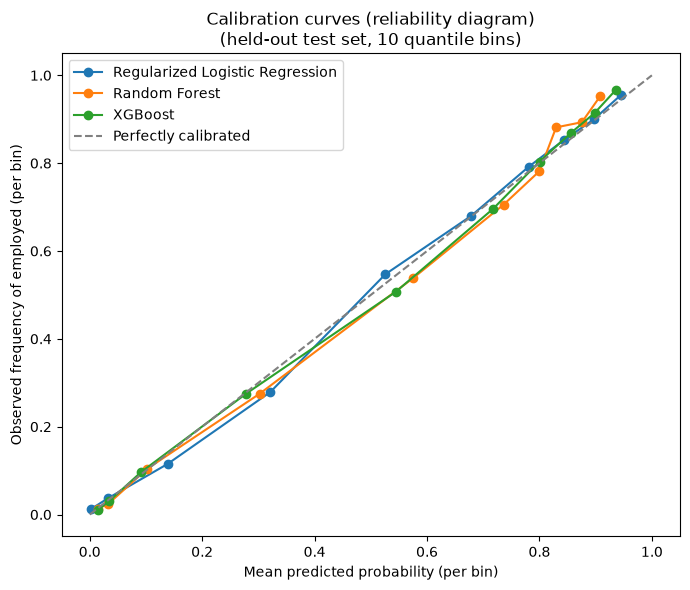

Saved calibration curve figure to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\figures\ml_calibration_curve.png


In [22]:
# Calibration curves for all three models, overlaid on one plot (consistent with the combined
# ROC curve above). Uses each model's already-computed test-set predicted probabilities from
# evaluation_results -- no model is retrained here.
fig, ax = plt.subplots(figsize=(7, 6))
for name, res in evaluation_results.items():
    prob_true, prob_pred = calibration_curve(y_test, res['y_proba'], n_bins=10, strategy='quantile')
    ax.plot(prob_pred, prob_true, marker='o', label=name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability (per bin)')
ax.set_ylabel('Observed frequency of employed (per bin)')
ax.set_title('Calibration curves (reliability diagram)\n(held-out test set, 10 quantile bins)')
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'ml_calibration_curve.png', dpi=150)
plt.show()

print('Saved calibration curve figure to:', FIGURES_DIR / 'ml_calibration_curve.png')

## 10. Save Outputs

In [23]:
ml_results_path = TABLES_DIR / 'ml_model_comparison.xlsx'
best_hyperparameters_df = pd.DataFrame([
    {'model': 'Regularized Logistic Regression', 'best_params': str(logreg_search.best_params_), 'best_cv_roc_auc': round(logreg_search.best_score_, 4)},
    {'model': 'Random Forest', 'best_params': str(rf_search.best_params_), 'best_cv_roc_auc': round(rf_search.best_score_, 4)},
    {'model': model3_name, 'best_params': str(model3_search.best_params_), 'best_cv_roc_auc': round(model3_search.best_score_, 4)},
])

with pd.ExcelWriter(ml_results_path) as writer:
    model_comparison_table.to_excel(writer, sheet_name='model_comparison', index=False)
    calibration_table.to_excel(writer, sheet_name='calibration_log_loss_brier', index=False)
    best_hyperparameters_df.to_excel(writer, sheet_name='best_hyperparameters', index=False)
    rf_importance_df.to_excel(writer, sheet_name='rf_feature_importance', index=False)
    xgb_importance_df.to_excel(writer, sheet_name='xgb_feature_importance', index=False)
    logreg_perm_importance_df.to_excel(writer, sheet_name='logreg_permutation_importance', index=False)
    variable_check_df.to_excel(writer, sheet_name='variable_availability', index=False)
    sample_missingness_df.to_excel(writer, sheet_name='missingness', index=False)
    split_balance.to_excel(writer, sheet_name='train_test_class_balance')

print('Saved ML model comparison results to:', ml_results_path)

Saved ML model comparison results to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\tables\ml_model_comparison.xlsx


In [24]:
best_model_object = MODEL_REGISTRY[best_model_name]
best_model_path = MODELS_DIR / 'best_ml_model.pkl'
joblib.dump(best_model_object, best_model_path)
print(f'Saved best-performing model ({best_model_name}, by test ROC AUC) to:', best_model_path)

Saved best-performing model (XGBoost, by test ROC AUC) to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\models\best_ml_model.pkl


In [25]:
ml_summary_lines = [
    '# Machine Learning Results Summary',
    '',
    'Generated by notebooks/06_machine_learning_models.ipynb. Machine learning is used here for',
    '**prediction performance and variable importance only** -- hypothesis testing (association',
    'direction, statistical significance) is the role of notebooks 04-05, not this notebook.',
    '',
    '## Modelling Sample',
    '',
    f'- Rows before listwise deletion: {n_before}',
    f'- Rows in modelling sample: {n_after} ({n_dropped} dropped due to missing values)',
    f'- Feature set (identical to notebook 05): {ALL_NUMERIC_FEATURE_VARS}',
    f'- Country one-hot dummy columns: {COUNTRY_DUMMY_COLS}',
    f'- Exact-duplicate rate on the final feature matrix (features + label): '
    f'{DEDUP_SUMMARY["dup_rate_features_plus_label"]:.1%}',
    ('- Deduplicated before splitting (exact feature+label duplicates removed): '
     f'{DEDUP_SUMMARY["rows_before_dedup"]} -> {DEDUP_SUMMARY["rows_after_dedup"]} rows'
     if DEDUP_SUMMARY['deduplicated'] else
     '- Duplicate rate not material (<= 1%); no deduplication applied'),
    f'- Train/test split: {len(X_train)} / {len(X_test)} rows (80/20, stratified on employed)',
    '',
    '## Model Comparison',
    '',
    model_comparison_table.to_markdown(index=False),
    '',
    f'Best-performing model on the held-out test set (by ROC AUC): **{best_model_name}**.',
    '',
    '## Calibration: Log Loss, Brier Score, Calibration Curve',
    '',
    'Accuracy, precision, recall, F1, and ROC AUC measure discrimination -- how well each model ranks '
    'or separates the two classes. Log Loss and Brier Score instead measure calibration -- whether '
    'predicted probabilities are themselves trustworthy as probabilities (both are lower-is-better '
    'scoring rules). Log Loss is the average negative log-likelihood of the true class under the '
    'predicted probabilities, and penalizes confident wrong predictions heavily; the Brier Score is '
    'the mean squared error between predicted probability and the true (0/1) outcome, and is a direct, '
    'bounded (0 to 1) measure of probability calibration. A model can rank cases well (high ROC AUC) '
    'while still being poorly calibrated (e.g. systematically over- or under-confident), which is why '
    'both are reported alongside the discrimination metrics above.',
    '',
    calibration_table.to_markdown(index=False),
    '',
    f'A calibration curve (reliability diagram) for the best-performing model ({best_model_name}) is '
    f'saved to outputs/figures/ml_calibration_curve.png, comparing mean predicted probability against '
    f'observed employment frequency across 10 quantile bins of the held-out test set.',
    '',
    '## Best Hyperparameters (small, controlled search -- not exhaustive)',
    '',
    best_hyperparameters_df.to_markdown(index=False),
    '',
    '## Explainability by Hypothesis (H1-H5)',
    '',
    'Random Forest -- total importance signal grouped by hypothesis:',
    '',
    rf_by_hypothesis.to_markdown(),
    '',
    f'{model3_name} -- total importance signal grouped by hypothesis:',
    '',
    xgb_by_hypothesis.to_markdown(),
    '',
    'Regularized Logistic Regression (permutation importance) -- total importance signal grouped by hypothesis:',
    '',
    logreg_by_hypothesis.to_markdown(),
    '',
    '## SHAP',
    '',
    shap_summary_note,
    '',
    '## Machine Learning vs. Econometrics',
    '',
    'Machine learning results above describe predictive accuracy and relative variable importance',
    'only. They do not establish statistically-tested association direction or significance -- that',
    'evidence comes from the econometric models in notebooks 04-05. Notebook 07 compares the two',
    'hypothesis-by-hypothesis without treating machine learning importance as a substitute for',
    'econometric hypothesis testing.',
]

ml_summary_path = REPORTS_DIR / 'ml_results_summary.md'
with open(ml_summary_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(ml_summary_lines))

print('Saved ML results summary to:', ml_summary_path)
print('Next step: notebooks/07_model_comparison_and_results.ipynb')

Saved ML results summary to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\reports\ml_results_summary.md
Next step: notebooks/07_model_comparison_and_results.ipynb
